# K-Nearest Neighbors - KNN Model

## KNN - (K-Nearest Neighbors)

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta)  
df.isnull().sum()

om                  0
yr                  0
mo                  0
dy                  0
date                0
time                0
tz                  0
datetime_utc        0
st                  0
stf                 0
mag               756
inj                 0
fat                 0
loss            27170
slat                0
slon                0
elat                0
elon                0
len                 0
wid                 0
ns                  0
sn                  0
f1                  0
f2                  0
f3                  0
f4                  0
fc                  0
dtype: int64

In [3]:
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
# Imputar los valores NaN con la media de la columna 'mag'
df['mag'] = df['mag'].fillna(df['mag'].mean())

In [4]:
df.isnull().sum()

om              0
yr              0
mo              0
dy              0
date            0
time            0
tz              0
datetime_utc    0
st              0
stf             0
mag             0
inj             0
fat             0
loss            0
slat            0
slon            0
elat            0
elon            0
len             0
wid             0
ns              0
sn              0
f1              0
f2              0
f3              0
f4              0
fc              0
dtype: int64

In [ ]:
pip install mglearn

In [ ]:
pip install -r requirements.txt

In [5]:
# Crear la columna 'mortality' en el DataFrame original
df['mortality'] = df['fat'].apply(lambda x: 0 if x == 0 else 1)

# Renombrar el DataFrame a 'mortality_target'
mortality_target = df

In [6]:
import numpy as np

# Crear la columna 'mortality' con 0 si 'fat' es 0, y 1 si 'fat' es mayor que 0
df['mortality'] = np.where(df['fat'] == 0, 0, 1)

# Contar la cantidad de ceros y unos
print("Cantidad de ceros:", (df['mortality'] == 0).sum())
print("Cantidad de unos:", (df['mortality'] == 1).sum())

# Asignar el DataFrame modificado a 'tornados.target'
tornados_target = df

Cantidad de ceros: 67120
Cantidad de unos: 1573


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = tornados_target[['om', 'yr', 'mo', 'dy', 'stf', 'mag', 'inj', 'loss', 'slat', 'slon', 'elat', 'elon', 'len', 'wid', 'ns', 'sn', 'f1', 'f2', 'f3', 'f4']]
y = df['mortality']

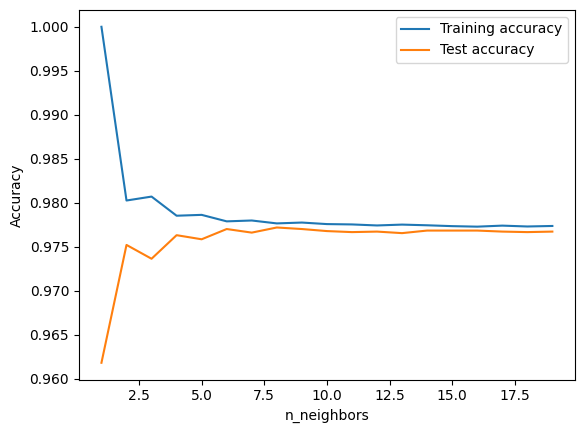

In [9]:
# Importar las bibliotecas necesarias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

# Seleccionar las características y la variable objetivo
X = tornados_target[['mag', 'slat', 'slon', 'elat', 'elon', 'len', 'wid','f1', 'f2', 'f3', 'f4']]
y = df['mortality']

# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=66)

# Listas para almacenar la exactitud en entrenamiento y prueba
training_accuracy = []
test_accuracy = []

# Configuración de los vecinos
neighbors_settings = range(1, 20)

# Bucle para ajustar el modelo con diferentes números de vecinos
for n_neighbors in neighbors_settings:
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    test_accuracy.append(clf.score(X_test, y_test))

# Graficar los resultados
plt.plot(neighbors_settings, training_accuracy, label="Training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="Test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend();

In [10]:
clf = KNeighborsClassifier(n_neighbors=12)
clf.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=12)

In [11]:
print(clf.score(X_train, y_train), clf.score(X_test, y_test))

0.9774063937576428 0.9767089786887155


In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
import numpy as np

In [13]:
# Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=66)

In [14]:
best_score = 0
for n_neighbors in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)        
    scores = cross_val_score(knn, X_train, y_train, cv=5) 
    score = np.mean(scores)
    if score > best_score:
        best_score = score
        best_parameters = {'n_neighbors': n_neighbors}
print("Best cross-validation accuracy: {:.2f}".format(best_score))
print("Best parameters: ", best_parameters)

Best cross-validation accuracy: 0.98
Best parameters:  {'n_neighbors': 19}


In [15]:
knn = KNeighborsClassifier(**best_parameters)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [16]:
print("Train set accuracy:", knn.score(X_train, y_train), "; Test set accuracy:", knn.score(X_test, y_test))

Train set accuracy: 0.9773481628137192 ; Test set accuracy: 0.9767089786887155


In [ ]:
pip install mglearn

In [33]:
import mglearn

In [ ]:
pip install neighbors

In [17]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_log_error
import numpy as np

rmsle_val = []
best_rmsle = 1.0

for k in range(100):
    k = k + 1
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train) 
    y_pred = knn.predict(X_test)
    rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    
    if rmsle < best_rmsle:
        best_rmsle = rmsle
        best_k = k
    
    rmsle_val.append(rmsle)
    print('RMSLE value for k= ', k, 'is:', rmsle)

print(f"Best RMSLE: {best_rmsle}, Best k: {best_k}")

RMSLE value for k=  1 is: 0.13546953854440158
RMSLE value for k=  2 is: 0.12090513126488696
RMSLE value for k=  3 is: 0.1155160159994345
RMSLE value for k=  4 is: 0.11212014930410885
RMSLE value for k=  5 is: 0.10967778662617866
RMSLE value for k=  6 is: 0.107567208273545
RMSLE value for k=  7 is: 0.1067041206147654
RMSLE value for k=  8 is: 0.10601265319438839
RMSLE value for k=  9 is: 0.10541229696287936
RMSLE value for k=  10 is: 0.10484507280056587
RMSLE value for k=  11 is: 0.10462340270845794
RMSLE value for k=  12 is: 0.10417262474443371
RMSLE value for k=  13 is: 0.10402800231487816
RMSLE value for k=  14 is: 0.10371766560078025
RMSLE value for k=  15 is: 0.10336422228363012
RMSLE value for k=  16 is: 0.10312909771182206
RMSLE value for k=  17 is: 0.10273767189003513
RMSLE value for k=  18 is: 0.10263497169263003
RMSLE value for k=  19 is: 0.10232120644202577
RMSLE value for k=  20 is: 0.10218604371919347
RMSLE value for k=  21 is: 0.10193943145636648
RMSLE value for k=  22 is:

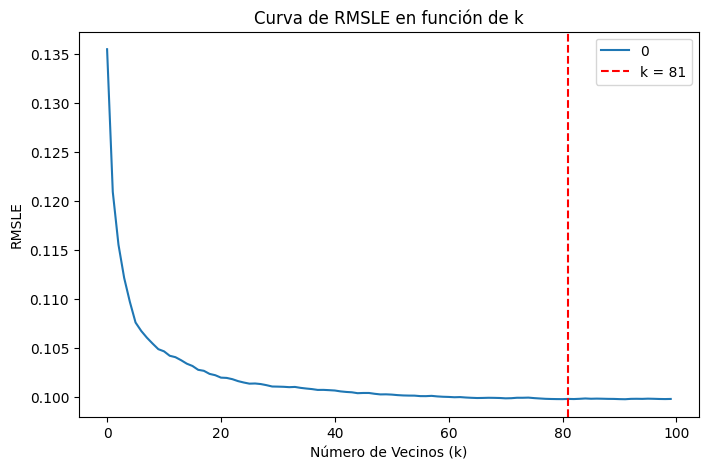

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

curve = pd.DataFrame(rmsle_val)
curve.plot(figsize=(8,5))

# Etiquetas para los ejes
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('RMSLE')

# Título opcional para mejorar la comprensión
plt.title('Curva de RMSLE en función de k')

# Resaltar k=81
plt.axvline(x=81, color='r', linestyle='--', label='k = 81')

# Añadir una leyenda para identificar la línea
plt.legend()

plt.show()

In [19]:
from sklearn.neighbors import KNeighborsRegressor  # Importa desde sklearn.neighbors

# Ahora puedes crear el modelo sin el error
knn = KNeighborsRegressor(n_neighbors=81)

knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
score = knn.score(X_test, y_test)

print(f"Score del modelo: {score}")

Score del modelo: 0.08045335027001854


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# Normalización de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo con los datos escalados
knn = KNeighborsRegressor(n_neighbors=31)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
score = knn.score(X_test_scaled, y_test)

print(f"Score del modelo después de escalar: {score}")

Score del modelo después de escalar: 0.2231022543147656


In [21]:
from sklearn.metrics import r2_score, mean_absolute_error, explained_variance_score, mean_squared_error, mean_squared_log_error

# Cálculos de las métricas
r2_valid = r2_score(y_test, y_pred)
mae_valid = mean_absolute_error(y_test, y_pred)
evs_valid = explained_variance_score(y_test, y_pred, multioutput='uniform_average')
rmse_valid = np.sqrt(mean_squared_error(y_test, y_pred))
rmsle_valid = np.sqrt(mean_squared_log_error(y_test, y_pred))

# Mostrar los resultados
print('R2 Valid:', r2_valid)
print('EVS Valid:', evs_valid)
print('MAE Valid:', mae_valid)
print('RMSE Valid:', rmse_valid)
print('RMSLE Valid:', rmsle_valid)

R2 Valid: 0.2231022543147656
EVS Valid: 0.22327390077095421
MAE Valid: 0.03371750996442483
RMSE Valid: 0.13180007759882814
RMSLE Valid: 0.09181801416368035


In [22]:
# Usaremos la columna 'st' del DataFrame original para identificar cada muestra en el test.
countries_test = df.loc[X_test.index, 'st']

# Organizar los valores reales y las predicciones en un DataFrame
data_prediction = list(zip(y_test, y_pred))
data_prediction = pd.DataFrame(data_prediction, columns=['Test', 'Prediction'])

# Establecer como índice los identificadores de cada muestra (en este caso, el valor de 'st')
data_prediction = data_prediction.set_index(countries_test)

data_prediction = list(zip(y_test,y_pred))
data_prediction = pd.DataFrame(data_prediction, columns=['Test','Prediction'])
data_prediction = data_prediction.set_index(countries_test)
data_prediction.head(20)

,Test,Prediction
st,,
KS,0,0.032258
OK,0,0.354839
KY,0,0.000000
ND,0,0.000000
NE,0,0.000000
IL,0,0.000000
SC,0,0.000000
MS,0,0.000000
KY,0,0.000000


In [37]:
import plotly.graph_objects as go
import numpy as np

# Preparar datos
data_3d = data_prediction.copy()
data_3d['st'] = data_3d.index.astype(str)
data_3d['Error'] = np.abs(data_3d['Test'] - data_3d['Prediction'])

# Crear el gráfico 3D
fig = go.Figure(data=[go.Scatter3d(
    x=data_3d['st'],                # Muestras
    y=data_3d['Test'],              # Valor real
    z=data_3d['Prediction'],        # Valor predicho
    mode='markers',
    marker=dict(
        size=8,
        color=data_3d['Error'],     # Color por error
        colorscale='Viridis',
        colorbar=dict(title='Error absoluto'),
        opacity=0.8
    ),
    text=[f"ST: {st}<br>Real: {real:.2f}<br>Pred: {pred:.2f}<br>Error: {err:.2f}" 
          for st, real, pred, err in zip(data_3d['st'], data_3d['Test'], data_3d['Prediction'], data_3d['Error'])],
    hoverinfo='text'
)])

# Ajustes de la escena
fig.update_layout(
    title='Comparación 3D con Error absoluto por color',
    scene=dict(
        xaxis_title='STATE',
        yaxis_title='Test',
        zaxis_title='Predicción'
    ),
    height=600
)

fig.show()

## Metricas Para KNN

In [38]:
# ------------------------
# Paso 1: Importar los paquetes necesarios
# ------------------------
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from joblib import dump, load
from time import time

# ------------------------
# Paso 2: Cargar los datos
# ------------------------
# Asegúrate de que esta parte sea correcta para tu caso
# X_train, X_test, y_train, y_test = ...

# ------------------------
# Paso 3: Definir el pipeline y el grid de hiperparámetros
# ------------------------
# Definir el pipeline con un escalador y el modelo KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de los datos
    ('knn', KNeighborsClassifier())  # Modelo KNN
])

# Definir el grid de hiperparámetros para KNN
param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9],  # Número de vecinos
    'knn__weights': ['uniform', 'distance']  # Tipo de peso
}

# ------------------------
# Paso 4: Entrenar el modelo KNN con GridSearchCV
# ------------------------
# Crear el objeto GridSearchCV
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, n_jobs=-1, scoring='accuracy')

# Medir el tiempo de entrenamiento
start_time = time()
grid_knn.fit(X_train, y_train)
training_time_knn = time() - start_time

# Guardar el modelo entrenado
dump(grid_knn, 'grid_knn.joblib')

# ------------------------
# Paso 5: Hacer predicciones con el mejor modelo
# ------------------------
y_pred_knn = grid_knn.best_estimator_.predict(X_test)
y_pred_proba_knn = grid_knn.best_estimator_.predict_proba(X_test)[:, 1]

# ------------------------
# Paso 6: Calcular las métricas del modelo
# ------------------------

# Métricas originales
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

# Ljung-Box p-value
lb_p_value_knn = acorr_ljungbox(y_test - y_pred_knn, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

# Jarque-Bera p-value
jb_p_value_knn = jarque_bera(y_test - y_pred_knn)[1]

# Métricas adicionales
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

# ------------------------
# Paso 7: Crear DataFrame con los resultados
# ------------------------
resultados_knn = pd.DataFrame({
    'Modelo': ['KNN optimizado (GridSearchCV)'],
    'MAPE': [f"{mape_knn:.2f}"],
    'RMSE': [f"{rmse_knn:.2f}"],
    'R Cuadrado': [f"{r2_knn:.2f}"],
    'Ljung-Box p-value': [f"{lb_p_value_knn:.2f}" if 'lb_p_value_knn' in locals() else None],
    'Jarque-Bera p-value': [f"{jb_p_value_knn:.2f}"],
    'Precision': [f"{precision_knn:.2f}"],
    'Recall': [f"{recall_knn:.2f}"],
    'Accuracy': [f"{accuracy_knn:.2f}"],
    'F1-Score': [f"{f1_knn:.2f}"],
    'AUC': [f"{auc_knn:.2f}"],
    'CPU time (s)': [round(training_time_knn, 2)]
})

# ------------------------
# Paso 8: Mostrar los resultados
# ------------------------
print("Métricas para el modelo KNN:")
display(resultados_knn)

Métricas para el modelo KNN:


,Modelo,MAPE,RMSE,R Cuadrado,Ljung-Box p-value,Jarque-Bera p-value,Precision,Recall,Accuracy,F1-Score,AUC,CPU time (s)
0,KNN optimizado (GridSearchCV),11276044251597.28,0.15,0.00,0.87,0.00,0.97,0.98,0.98,0.97,0.82,55.73
